# Predictive Analysis for Cardiac Diagnosis: Prioritizing Comprehensive Patient Identification

## Problem

In this project, we delve into a dataset encapsulating various health metrics 

from __heart patients__, including age, blood pressure, heart rate, and more. 

Our goal is to develop a predictive model capable of accurately identifying individuals with heart disease. 

Given the grave implications of missing a positive diagnosis, our primary emphasis is on 

ensuring that the model identifies all potential patients, making recall for the positive class a crucial metric.

In [65]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from scipy.stats import boxcox
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier

%matplotlib inline

In [66]:
# Read dataset
df = pd.read_csv('heart.csv')
df.head() 

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [67]:
# Display a summary of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [68]:
# Define the continuous features
continuous_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# Identify the features to be converted to object data type
features_to_convert = [feature for feature in df.columns if feature not in continuous_features]

# Convert the identified features to object data type
df[features_to_convert] = df[features_to_convert].astype('object')

df.dtypes

age           int64
sex          object
cp           object
trestbps      int64
chol          int64
fbs          object
restecg      object
thalach       int64
exang        object
oldpeak     float64
slope        object
ca           object
thal         object
target       object
dtype: object

In [69]:
# Get the summary statistics for numerical variables
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
trestbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
thalach,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


In [70]:
# Get the summary statistics for categorical variables
df.describe(include='object')

,sex,cp,fbs,restecg,exang,slope,ca,thal,target
count,303,303,303,303,303,303,303,303,303
unique,2,4,2,3,2,3,5,4,2
top,1,0,0,1,0,2,0,2,1
freq,207,143,258,152,204,142,175,166,165


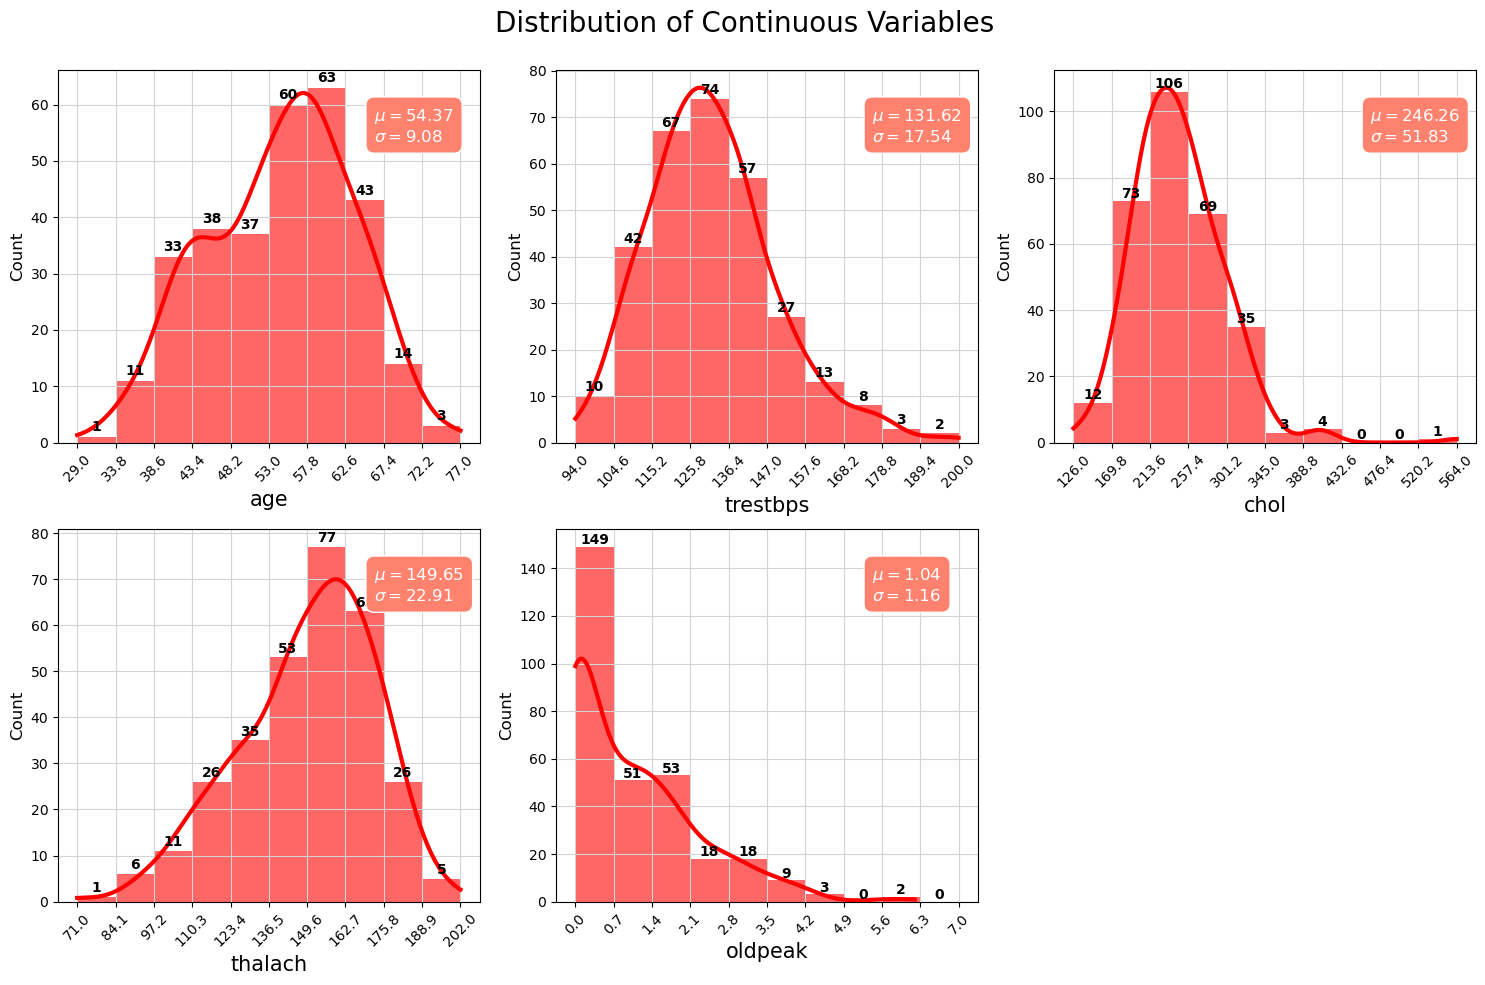

In [71]:
# Filter continuous features for the univariate analysis
df_continuous = df[continuous_features]

# Set up the subplot
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))

# Loop to plot histograms for each continuous feature
for i, col in enumerate(df_continuous.columns):
    x = i // 3
    y = i % 3
    values, bin_edges = np.histogram(df_continuous[col], 
                                     range=(np.floor(df_continuous[col].min()), np.ceil(df_continuous[col].max())))
    
    graph = sns.histplot(data=df_continuous, x=col, bins=bin_edges, kde=True, ax=ax[x, y],
                         edgecolor='none', color='red', alpha=0.6, line_kws={'lw': 3})
    ax[x, y].set_xlabel(col, fontsize=15)
    ax[x, y].set_ylabel('Count', fontsize=12)
    ax[x, y].set_xticks(np.round(bin_edges, 1))
    ax[x, y].set_xticklabels(ax[x, y].get_xticks(), rotation=45)
    ax[x, y].grid(color='lightgrey')
    
    for j, p in enumerate(graph.patches):
        ax[x, y].annotate('{}'.format(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height() + 1),
                          ha='center', fontsize=10, fontweight="bold")
    
    textstr = '\n'.join((
        r'$\mu=%.2f$' % df_continuous[col].mean(),
        r'$\sigma=%.2f$' % df_continuous[col].std()
    ))
    ax[x, y].text(0.75, 0.9, textstr, transform=ax[x, y].transAxes, fontsize=12, verticalalignment='top',
                  color='white', bbox=dict(boxstyle='round', facecolor='#ff826e', edgecolor='white', pad=0.5))

ax[1,2].axis('off')
plt.suptitle('Distribution of Continuous Variables', fontsize=20)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

## Inferences:

Looking at the histograms above, here's what I'm seeing for each numeric feature:

* **Age**: Patients are mostly middle-aged to older, roughly between 40 and 65, with a bit of a bump around the late 50s. Mean is about 54 years (std ~9), so there's a decent spread but no one extreme.
* **Resting blood pressure (`trestbps`)**: Most values sit in the 120-140 mm Hg range, which is roughly normal-to-borderline-high blood pressure. Mean ~131.6, std ~17.5 — a fairly tight distribution with a slight right tail (some patients with much higher readings).
* **Cholesterol (`chol`)**: Centered around 200-300 mg/dl, mean ~246. This is on the higher side clinically (above 200 is usually considered elevated), so a good chunk of this dataset already has a cholesterol-related risk factor.
* **Max heart rate achieved (`thalach`)**: Fairly wide spread from ~140 to 170 bpm during the stress test, mean ~150. Makes sense since this depends a lot on age and fitness level.
* **ST depression (`oldpeak`)**: Heavily skewed toward 0 — most patients show little to no ST depression during exercise, with a long tail of higher values for a smaller group. This one clearly isn't normally distributed, which is something I'll need to deal with before feeding it into distance-based models like KNN/SVM.

In [72]:
# Filter categorical features for the univariate analysis
categorical_features = df.columns.difference(continuous_features)
df_categorical = df[categorical_features]

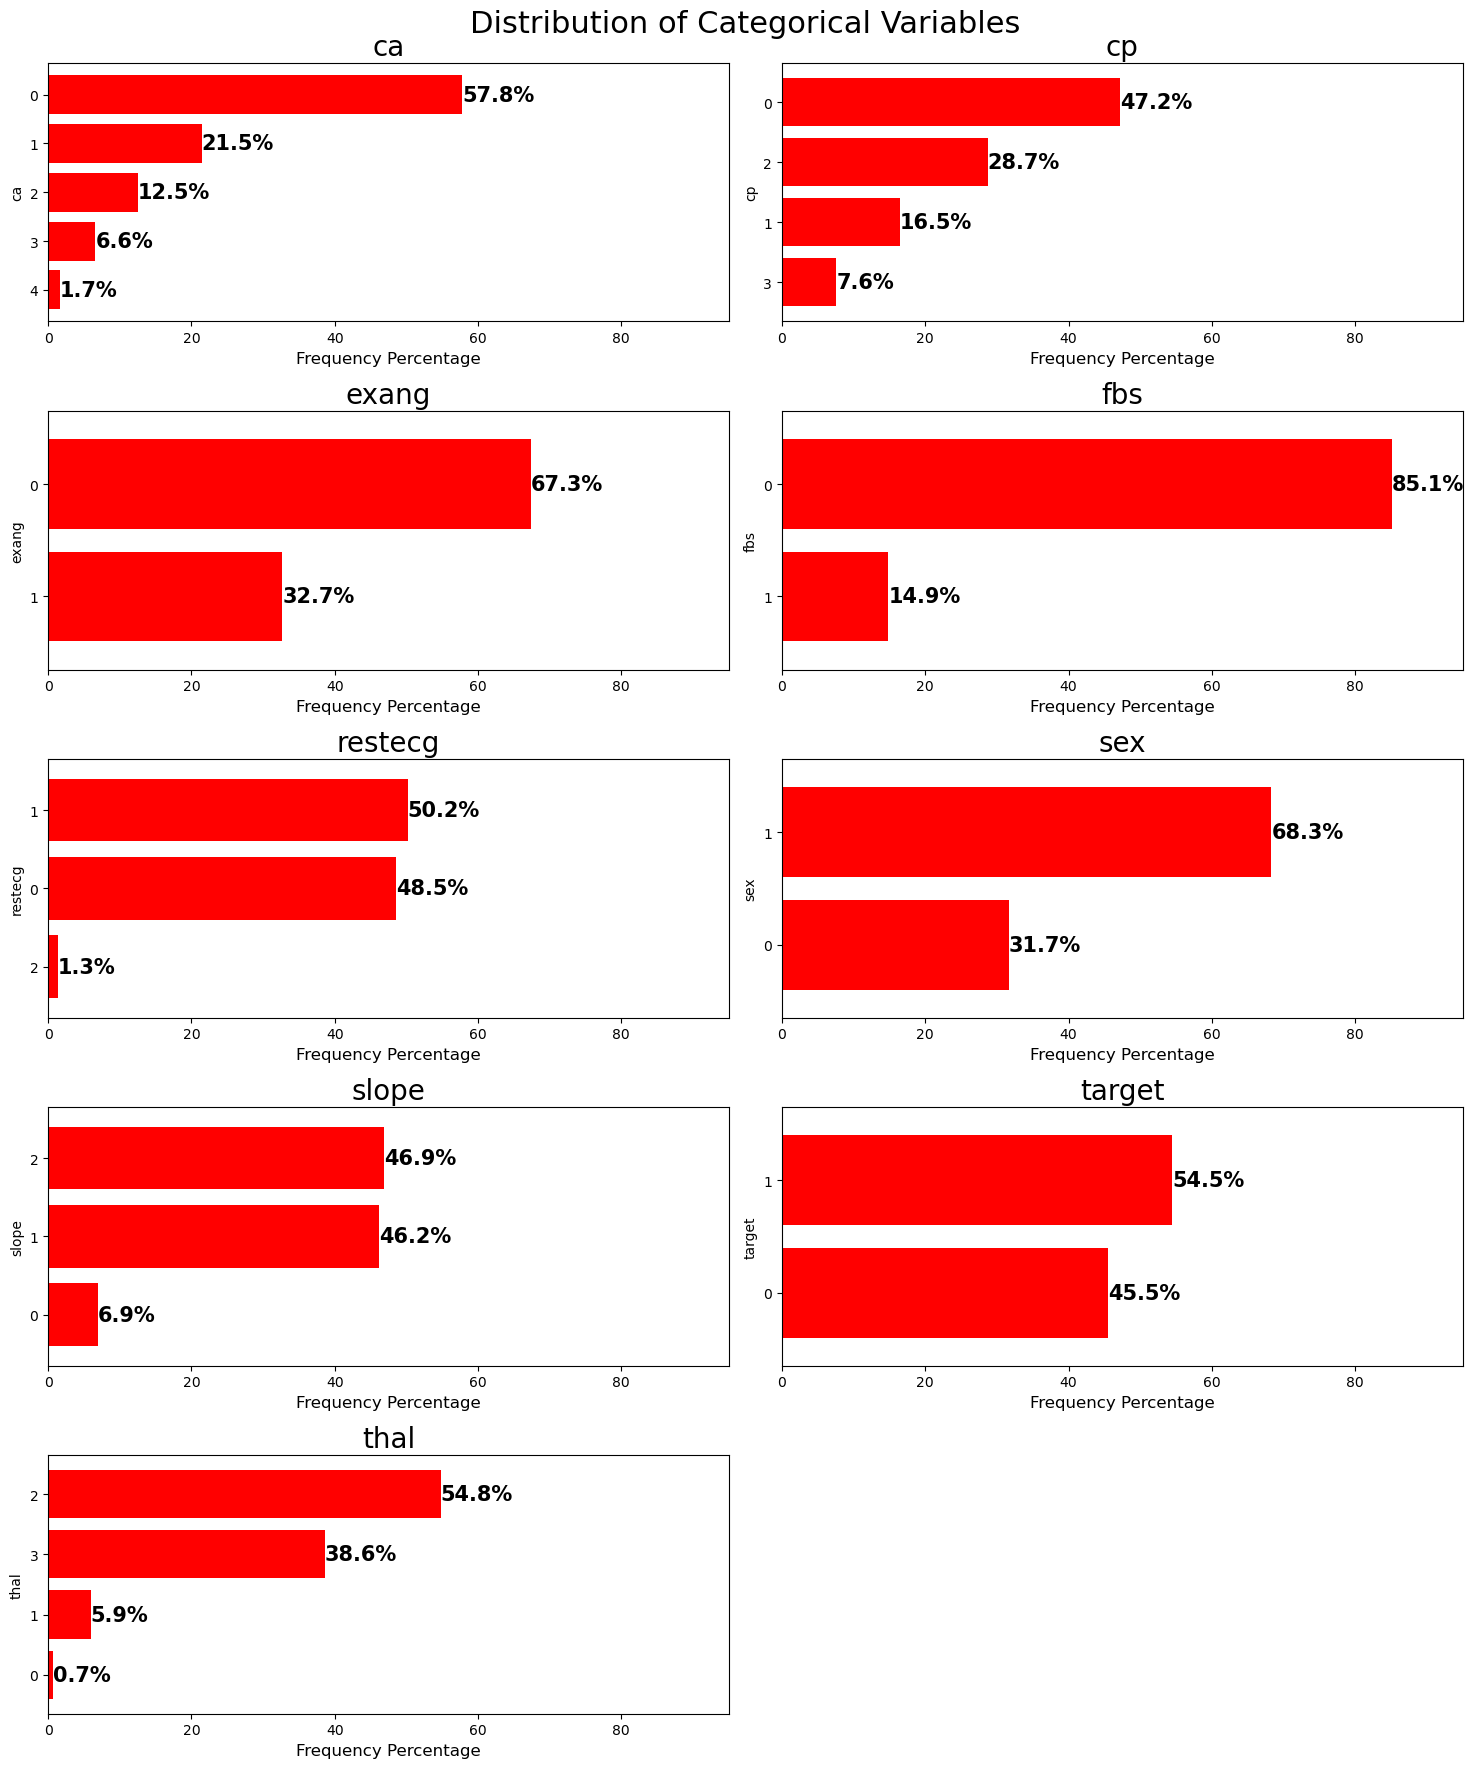

In [73]:
# Set up the subplot for a 4x2 layout
fig, ax = plt.subplots(nrows=5, ncols=2, figsize=(15, 18))

# Loop to plot bar charts for each categorical feature in the 4x2 layout
for i, col in enumerate(categorical_features):
    row = i // 2
    col_idx = i % 2
    
    # Calculate frequency percentages
    value_counts = df[col].value_counts(normalize=True).mul(100).sort_values()
    
    # Plot bar chart
    value_counts.plot(kind='barh', ax=ax[row, col_idx], width=0.8, color='red')
    
    # Add frequency percentages to the bars
    for index, value in enumerate(value_counts):
        ax[row, col_idx].text(value, index, str(round(value, 1)) + '%', fontsize=15, weight='bold', va='center')
    
    ax[row, col_idx].set_xlim([0, 95])
    ax[row, col_idx].set_xlabel('Frequency Percentage', fontsize=12)
    ax[row, col_idx].set_title(f'{col}', fontsize=20)

ax[4,1].axis('off')
plt.suptitle('Distribution of Categorical Variables', fontsize=22)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

## Inferences:

Going through the categorical bar charts one at a time:

* **Sex (`sex`)**: About 68% of the dataset is coded as `1` and 32% as `0`. In this dataset, `1` = male and `0` = female, so this is a male-majority sample — something to keep in mind since it could bias the model toward patterns more common in men.
* **Chest pain type (`cp`)**: Type 0 (typical angina) is the most common category by a good margin, with the other three types making up smaller, roughly similar shares.
* **Fasting blood sugar (`fbs`)**: Around 85% of patients have fasting blood sugar under 120 mg/dl, so high blood sugar is the exception here, not the rule.
* **Resting ECG (`restecg`)**: Type 1 is the most frequent result, with type 0 close behind and type 2 rare — worth remembering since a rare category can be noisy for the model to learn from.
* **Exercise-induced angina (`exang`)**: Most patients (~67%) did *not* experience angina during exercise.
* **Slope**: Type 2 is the most common slope value, with the other two types less frequent.
* **Number of major vessels (`ca`)**: Overwhelmingly `0` is the most common value — most patients have no vessels colored by fluoroscopy.
* **Thal**: Type 2 dominates, similar to what I saw with `restecg` — a few categories are much rarer than others across this dataset, which is something to watch for when one-hot encoding later since rare categories can end up with very few examples in the training set.

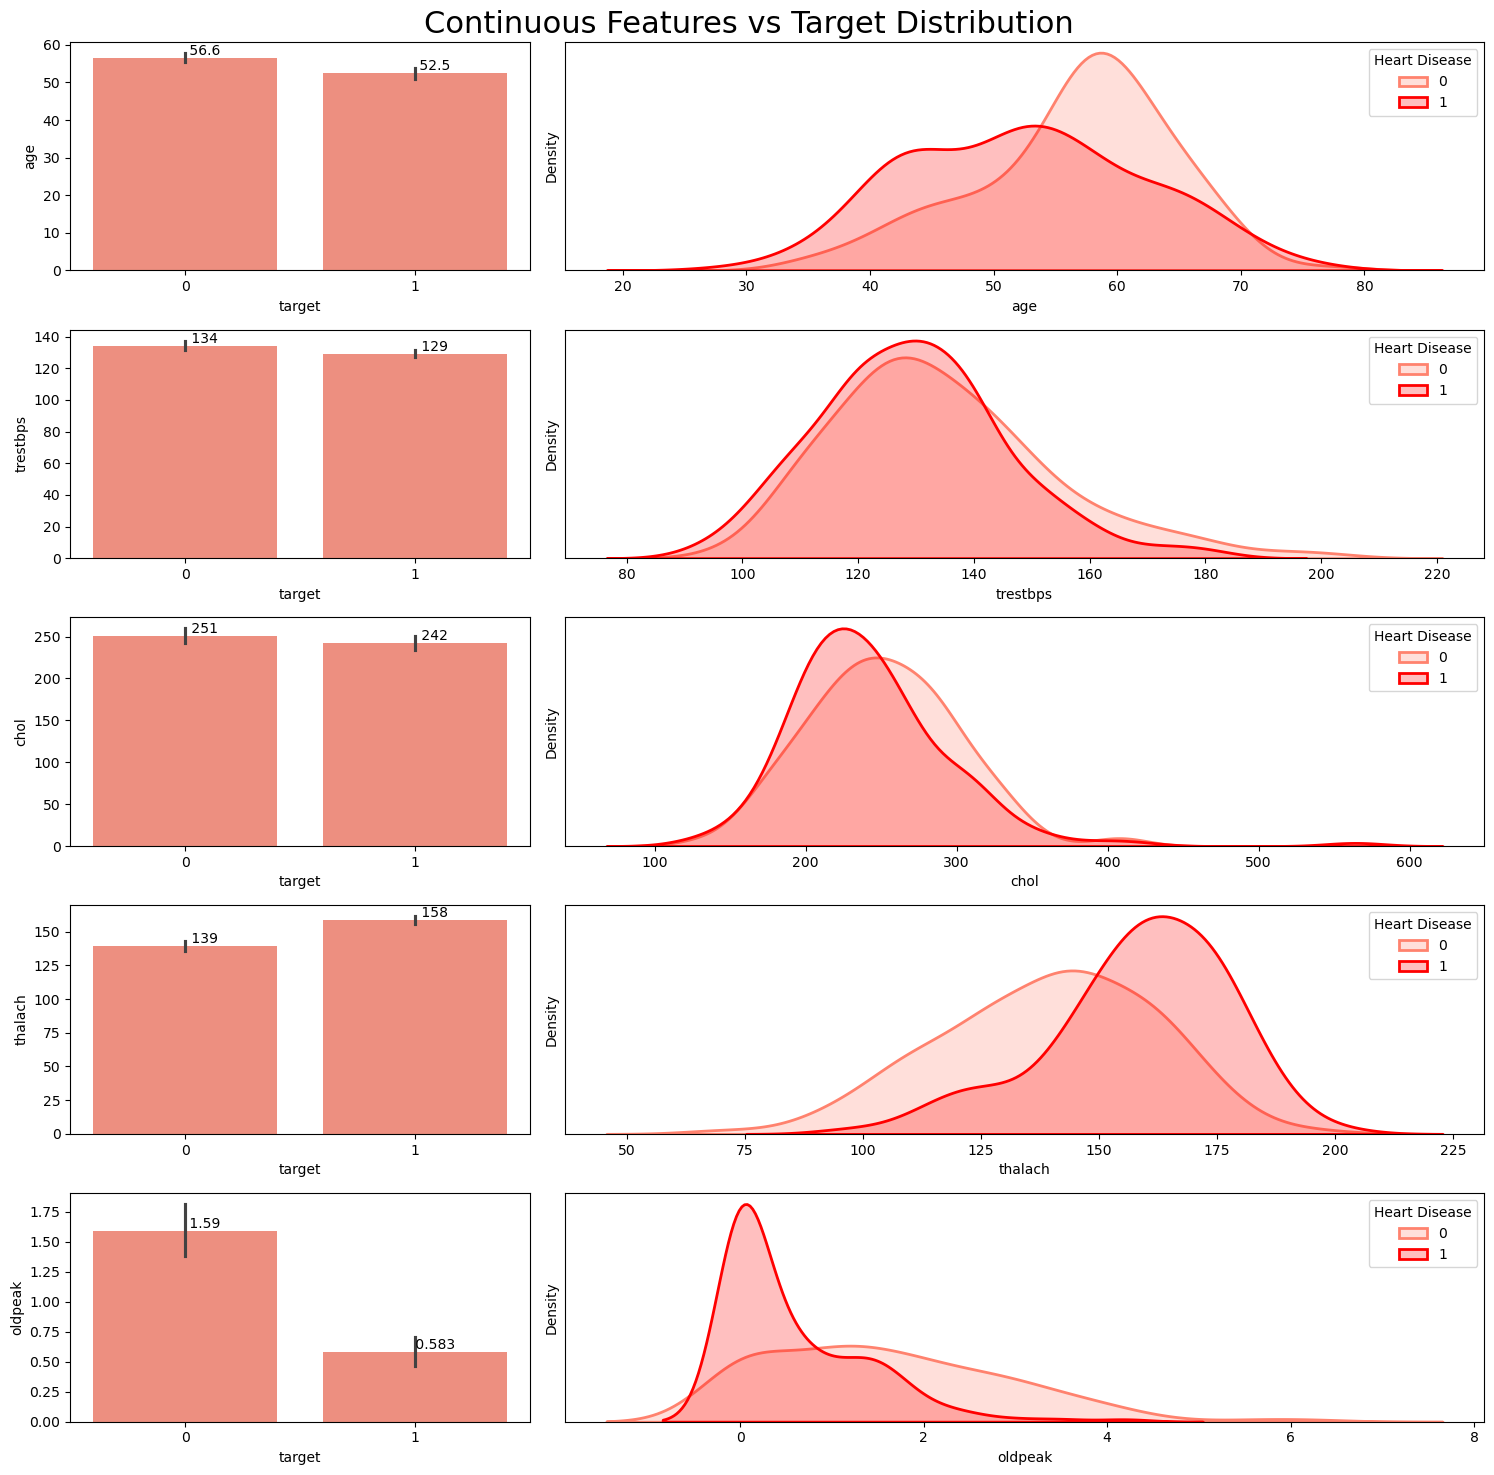

In [74]:
# Set color palette
sns.set_palette(['#ff826e', 'red'])

# Create the subplots
fig, ax = plt.subplots(len(continuous_features), 2, figsize=(15,15), gridspec_kw={'width_ratios': [1, 2]})

# Loop through each continuous feature to create barplots and kde plots
for i, col in enumerate(continuous_features):
    # Barplot showing the mean value of the feature for each target category
    graph = sns.barplot(data=df, x="target", y=col, ax=ax[i,0])
    
    # KDE plot showing the distribution of the feature for each target category
    sns.kdeplot(data=df[df["target"]==0], x=col, fill=True, linewidth=2, ax=ax[i,1], label='0')
    sns.kdeplot(data=df[df["target"]==1], x=col, fill=True, linewidth=2, ax=ax[i,1], label='1')
    ax[i,1].set_yticks([])
    ax[i,1].legend(title='Heart Disease', loc='upper right')
    
    # Add mean values to the barplot
    for cont in graph.containers:
        graph.bar_label(cont, fmt='         %.3g')
        
# Set the title for the entire figure
plt.suptitle('Continuous Features vs Target Distribution', fontsize=22)
plt.tight_layout()                     
plt.show()


## Inferences:

Comparing each numeric feature against the target (heart disease vs. no heart disease):

* **Age**: A bit counter-intuitive — patients *with* heart disease are on average slightly *younger* than those without. I wouldn't have guessed that, but it lines up with the idea that this dataset may include younger patients with other strong risk factors (like chest pain type or vessel count) driving the diagnosis rather than age alone.
* **Resting blood pressure**: The two groups look almost identical here — the KDE curves overlap heavily and the means are close. This tells me `trestbps` alone probably isn't going to be a strong predictor.
* **Cholesterol**: Similar story — the distributions overlap a lot, though the heart-disease group has a slightly *lower* average cholesterol, which again isn't the direction I expected going in.
* **Max heart rate (`thalach`)**: This one actually shows a real difference — patients with heart disease tend to reach a noticeably higher max heart rate during the stress test. This looks like one of the more useful continuous features.
* **ST depression (`oldpeak`)**: Also a clear separation — patients with heart disease cluster tightly near 0, while patients without disease have a wider spread with higher values. So lower `oldpeak` is associated with the positive class here.

Overall, `thalach` and `oldpeak` look like they'll carry more predictive signal than `trestbps` or `chol`.

In [75]:
# Remove 'target' from the categorical_features
categorical_features = [feature for feature in categorical_features if feature != 'target']

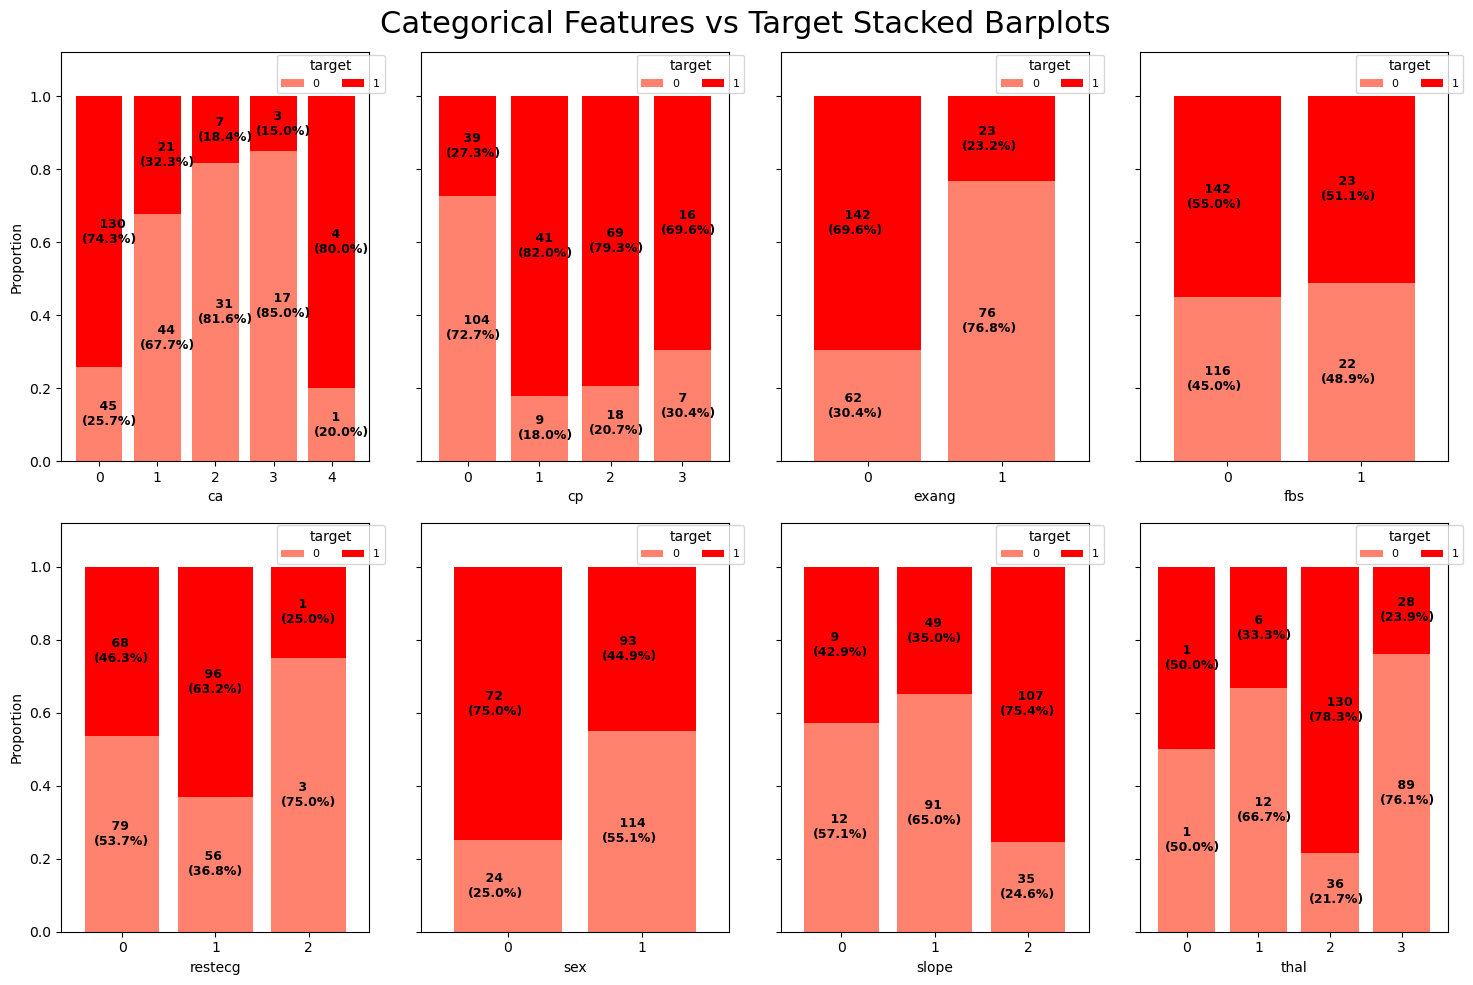

In [76]:
fig, ax = plt.subplots(nrows=2, ncols=4, figsize=(15,10))

for i,col in enumerate(categorical_features):
    
    # Create a cross tabulation showing the proportion of purchased and non-purchased loans for each category of the feature
    cross_tab = pd.crosstab(index=df[col], columns=df['target'])
    
    # Using the normalize=True argument gives us the index-wise proportion of the data
    cross_tab_prop = pd.crosstab(index=df[col], columns=df['target'], normalize='index')

    # Define colormap
    cmp = ListedColormap(['#ff826e', 'red'])
    
    # Plot stacked bar charts
    x, y = i//4, i%4
    cross_tab_prop.plot(kind='bar', ax=ax[x,y], stacked=True, width=0.8, colormap=cmp,
                        legend=False, ylabel='Proportion', sharey=True)
    
    # Add the proportions and counts of the individual bars to our plot
    for idx, val in enumerate([*cross_tab.index.values]):
        for (proportion, count, y_location) in zip(cross_tab_prop.loc[val],cross_tab.loc[val],cross_tab_prop.loc[val].cumsum()):
            ax[x,y].text(x=idx-0.3, y=(y_location-proportion)+(proportion/2)-0.03,
                         s = f'    {count}\n({np.round(proportion * 100, 1)}%)', 
                         color = "black", fontsize=9, fontweight="bold")
    
    # Add legend
    ax[x,y].legend(title='target', loc=(0.7,0.9), fontsize=8, ncol=2)
    # Set y limit
    ax[x,y].set_ylim([0,1.12])
    # Rotate xticks
    ax[x,y].set_xticklabels(ax[x,y].get_xticklabels(), rotation=0)
    
            
plt.suptitle('Categorical Features vs Target Stacked Barplots', fontsize=22)
plt.tight_layout()                     
plt.show()

## Inferences:

From the stacked bar charts of each categorical feature against the target:

* **Number of major vessels (`ca`)**: Patients with 0 vessels colored have a much higher rate of heart disease, and that rate drops as the vessel count goes up. This makes clinical sense too — fewer visibly blocked/narrowed vessels on this particular test doesn't necessarily mean healthier, but in this dataset it's clearly correlated with the positive class.
* **Chest pain type (`cp`)**: Types 1, 2, and 3 all show a higher proportion of heart disease compared to type 0 (typical angina). That's a bit surprising since I'd expect "typical" angina to be the most closely linked to heart disease, but the data says otherwise — this looks like a genuinely useful feature.
* **Exercise-induced angina (`exang`)**: Patients who did *not* have exercise-induced angina show a higher rate of heart disease than those who did — another one that runs against my intuition, but it's consistent enough in the plot to matter.
* **Fasting blood sugar (`fbs`)**: The split between the two groups looks pretty even, so this feature probably isn't adding much on its own.
* **Resting ECG (`restecg`)**: Type 1 shows a higher proportion of heart disease compared to the others, so this might contribute some signal.
* **Sex**: Since `1` = male and `0` = female in this dataset, this chart shows males have a *lower* proportion of heart disease than females do here — which is actually the opposite of what's typically reported in the general population, so this could just be a quirk of the particular sample rather than a real medical relationship. Worth flagging as something to interpret cautiously.
* **Slope**: The proportions vary across the three slope categories, with one type standing out as more associated with heart disease, though the sample sizes for some slope categories are small enough that I wouldn't put too much weight on that pattern.

Overall, `ca`, `cp`, and `exang` look like the strongest categorical predictors from this analysis.

In [77]:
# Check for missing values in the dataset
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [78]:
#IQR Method
Q1 = df[continuous_features].quantile(0.25)
Q3 = df[continuous_features].quantile(0.75)
IQR = Q3 - Q1
outliers_count_specified = ((df[continuous_features] < (Q1 - 1.5 * IQR)) | (df[continuous_features] > (Q3 + 1.5 * IQR))).sum()

outliers_count_specified

age         0
trestbps    9
chol        5
thalach     1
oldpeak     5
dtype: int64

## Inference:

The IQR method flags a small number of outliers per feature: 9 in `trestbps`, 5 in `chol`, 5 in `oldpeak`, just 1 in `thalach`, and none in `age`. None of these counts are large relative to the 303 total records (all under 3%), and clinically these could easily be real high-risk patients (e.g. unusually high blood pressure or cholesterol) rather than data entry mistakes. Because of that, I decided **not to drop or cap them** — removing genuine high-risk patients could actually hurt the model's ability to catch real heart disease cases, which is exactly what we're trying to optimize for (recall on the positive class). The Box-Cox transformation applied later on the continuous features should also help reduce how much these few extreme values can skew the distance-based models (KNN, SVM).

In [79]:
# Implementing one-hot encoding on the specified categorical features
df_encoded = pd.get_dummies(df, columns=['cp', 'restecg', 'thal'], drop_first=True)

# Convert the rest of the categorical variables that don't need one-hot encoding to integer data type
features_to_convert = ['sex', 'fbs', 'exang', 'slope', 'ca', 'target']
for feature in features_to_convert:
    df_encoded[feature] = df_encoded[feature].astype(int)

df_encoded.dtypes

age            int64
sex            int64
trestbps       int64
chol           int64
fbs            int64
thalach        int64
exang          int64
oldpeak      float64
slope          int64
ca             int64
target         int64
cp_1            bool
cp_2            bool
cp_3            bool
restecg_1       bool
restecg_2       bool
thal_1          bool
thal_2          bool
thal_3          bool
dtype: object

In [80]:
# Displaying the resulting DataFrame after one-hot encoding
df_encoded.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,slope,ca,target,cp_1,cp_2,cp_3,restecg_1,restecg_2,thal_1,thal_2,thal_3
0,63,1,145,233,1,150,0,2.3,0,0,1,False,False,True,False,False,True,False,False
1,37,1,130,250,0,187,0,3.5,0,0,1,False,True,False,True,False,False,True,False
2,41,0,130,204,0,172,0,1.4,2,0,1,True,False,False,False,False,False,True,False
3,56,1,120,236,0,178,0,0.8,2,0,1,True,False,False,True,False,False,True,False
4,57,0,120,354,0,163,1,0.6,2,0,1,False,False,False,True,False,False,True,False


In [81]:
# Define the features (X) and the output labels (y)
X = df_encoded.drop('target', axis=1)
y = df_encoded['target'] 

In [82]:
# Splitting data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

In [83]:
X_train.shape,X_test.shape

((242, 18), (61, 18))

In [84]:
# Adding a small constant to 'oldpeak' to make all values positive
X_train['oldpeak'] = X_train['oldpeak'] + 0.001
X_test['oldpeak'] = X_test['oldpeak'] + 0.001

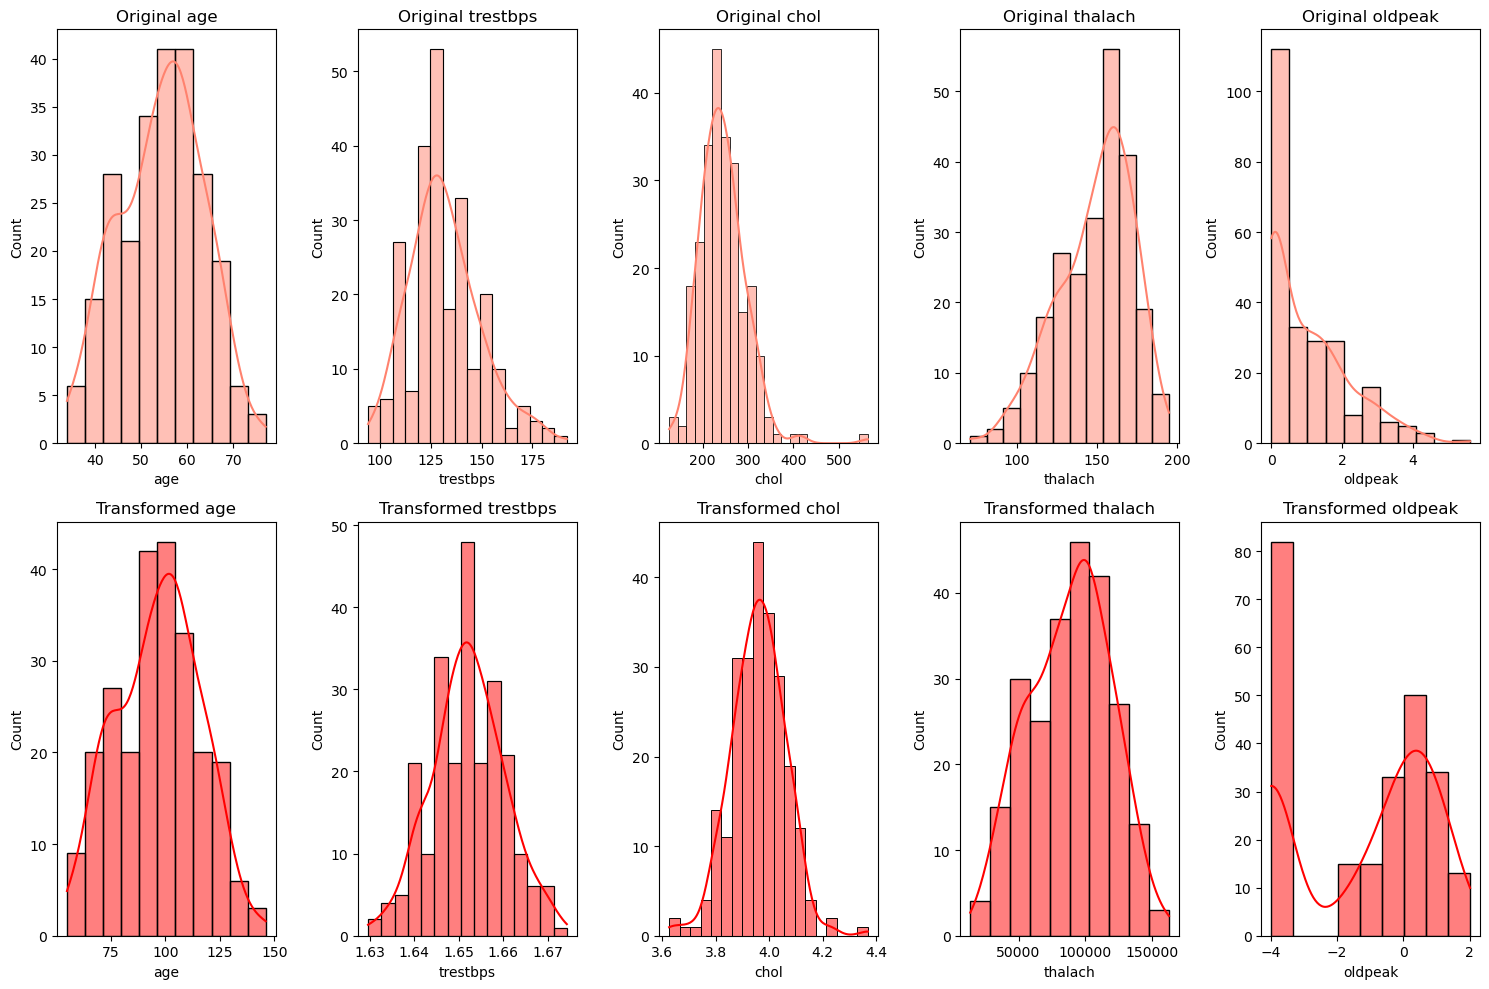

In [85]:
# Checking the distribution of the continuous features
fig, ax = plt.subplots(2, 5, figsize=(15,10))

# Original Distributions
for i, col in enumerate(continuous_features):
    sns.histplot(X_train[col], kde=True, ax=ax[0,i], color='#ff826e').set_title(f'Original {col}')
    

# Applying Box-Cox Transformation
# Dictionary to store lambda values for each feature
lambdas = {}

for i, col in enumerate(continuous_features):
    # Only apply box-cox for positive values
    if X_train[col].min() > 0:
        X_train[col], lambdas[col] = boxcox(X_train[col])
        # Applying the same lambda to test data
        X_test[col] = boxcox(X_test[col], lmbda=lambdas[col]) 
        sns.histplot(X_train[col], kde=True, ax=ax[1,i], color='red').set_title(f'Transformed {col}')
    else:
        sns.histplot(X_train[col], kde=True, ax=ax[1,i], color='green').set_title(f'{col} (Not Transformed)')

fig.tight_layout()
plt.show()

## Inference:

I applied a Box-Cox transformation to the continuous features to make their distributions closer to normal (useful for models like Logistic Regression and SVM that assume/benefit from roughly normal, similarly-scaled inputs):

* **Age**: Became noticeably more symmetric after the transform.
* **`trestbps`**: Also came out closer to normal, with less of the right-skew it had originally.
* **`chol`**: Same story — the transform pulled in the right tail and made it look more bell-shaped.
* **`thalach`**: This one was already fairly symmetric to begin with, so the transform didn't change much — which makes sense since Box-Cox has less work to do on a feature that's already close to normal.
* **`oldpeak`**: This was the hardest one. Even after transforming, it's still not very normal-looking, probably because so many values are stacked right at 0. A log or Box-Cox transform can't fully fix that kind of "spike at zero" shape — something like Yeo-Johnson (which handles zeros/negatives more gracefully) might do a bit better, but I don't think this feature will ever look fully normal given how the underlying data is distributed.

In [86]:
X_train.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,slope,ca,cp_1,cp_2,cp_3,restecg_1,restecg_2,thal_1,thal_2,thal_3
269,99.775363,1,1.652121,4.044511,1,34193.227632,1,0.490856,0,0,False,False,False,False,False,False,False,True
191,104.060287,1,1.651135,3.909224,0,61564.640490,1,0.846853,1,3,False,False,False,False,False,False,False,True
15,87.096593,0,1.646937,3.916243,0,97354.894861,0,0.490856,1,0,False,True,False,True,False,False,True,False
224,95.519188,1,1.641028,3.960431,0,55975.891019,1,1.130195,1,1,False,False,False,True,False,False,False,True
250,89.190732,1,1.656716,4.069855,0,51729.486474,1,1.634849,1,3,False,False,False,True,False,False,False,True


### DT Base Model

In [87]:
# Define the base DT model
dt_base = DecisionTreeClassifier(random_state=0)

In [88]:
def tune_clf_hyperparameters(clf, param_grid, X_train, y_train, scoring='recall', n_splits=3):
    
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=0)
    
    clf_grid = GridSearchCV(clf, param_grid, cv=cv, scoring=scoring, n_jobs=-1)
    
    clf_grid.fit(X_train, y_train)
    
    best_hyperparameters = clf_grid.best_params_
    
    return clf_grid.best_estimator_, best_hyperparameters

In [89]:
# Hyperparameter grid for DT
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2,3],
    'min_samples_split': [2, 3, 4],
    'min_samples_leaf': [1, 2]
}

In [90]:
# Call the function for hyperparameter tuning
best_dt, best_dt_hyperparams = tune_clf_hyperparameters(dt_base, param_grid_dt, X_train, y_train)

In [91]:
print('DT Optimal Hyperparameters: \n', best_dt_hyperparams)

DT Optimal Hyperparameters: 
 {'criterion': 'entropy', 'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [92]:
# Evaluate the optimized model on the train data
print(classification_report(y_train, best_dt.predict(X_train)))

              precision    recall  f1-score   support

           0       0.73      0.75      0.74       110
           1       0.78      0.77      0.78       132

    accuracy                           0.76       242
   macro avg       0.76      0.76      0.76       242
weighted avg       0.76      0.76      0.76       242



In [93]:
# Evaluate the optimized model on the test data
print(classification_report(y_test, best_dt.predict(X_test)))

              precision    recall  f1-score   support

           0       0.80      0.71      0.75        28
           1       0.78      0.85      0.81        33

    accuracy                           0.79        61
   macro avg       0.79      0.78      0.78        61
weighted avg       0.79      0.79      0.79        61



In [94]:
def evaluate_model(model, X_test, y_test, model_name):

    y_pred = model.predict(X_test)

    report = classification_report(y_test, y_pred, output_dict=True)

    metrics = {
        "precision_0": report["0"]["precision"],
        "precision_1": report["1"]["precision"],
        "recall_0": report["0"]["recall"],
        "recall_1": report["1"]["recall"],
        "f1_0": report["0"]["f1-score"],
        "f1_1": report["1"]["f1-score"],
        "macro_avg_precision": report["macro avg"]["precision"],
        "macro_avg_recall": report["macro avg"]["recall"],
        "macro_avg_f1": report["macro avg"]["f1-score"],
        "accuracy": accuracy_score(y_test, y_pred)
    }
    
    df = pd.DataFrame(metrics, index=[model_name]).round(2)
    
    return df

In [95]:
dt_evaluation = evaluate_model(best_dt, X_test, y_test, 'DT')
dt_evaluation

,precision_0,precision_1,recall_0,recall_1,f1_0,f1_1,macro_avg_precision,macro_avg_recall,macro_avg_f1,accuracy
DT,0.8,0.78,0.71,0.85,0.75,0.81,0.79,0.78,0.78,0.79


## Inference:

The Decision Tree does reasonably well out of the box: 79% accuracy on test, with recall of 0.85 on the positive (disease) class — meaning it catches most true heart disease cases. Train and test scores are close (0.76 vs 0.79 accuracy), so it doesn't look like it's overfitting, which makes sense given the grid search kept `max_depth` shallow (2). It's a decent baseline, but I'd expect ensemble methods built on top of trees (like Random Forest or AdaBoost) to do better by combining multiple trees instead of relying on one.

### RF Base Model

In [96]:
rf_base = RandomForestClassifier(random_state=0)

In [97]:
param_grid_rf = {
    'n_estimators': [10, 30, 50, 70, 100],
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4],
    'min_samples_split': [2, 3, 4, 5],
    'min_samples_leaf': [1, 2, 3],
    'bootstrap': [True, False]
}

In [98]:
# Using the tune_clf_hyperparameters function to get the best estimator
best_rf, best_rf_hyperparams = tune_clf_hyperparameters(rf_base, param_grid_rf, X_train, y_train)

print('RF Optimal Hyperparameters: \n', best_rf_hyperparams)

RF Optimal Hyperparameters: 
 {'bootstrap': True, 'criterion': 'gini', 'max_depth': 2, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 30}


In [99]:
# Evaluate the optimized model on the train data
print(classification_report(y_train, best_rf.predict(X_train)))

              precision    recall  f1-score   support

           0       0.84      0.79      0.81       110
           1       0.83      0.87      0.85       132

    accuracy                           0.83       242
   macro avg       0.83      0.83      0.83       242
weighted avg       0.83      0.83      0.83       242



In [100]:

print(classification_report(y_train, best_rf.predict(X_train)))

              precision    recall  f1-score   support

           0       0.84      0.79      0.81       110
           1       0.83      0.87      0.85       132

    accuracy                           0.83       242
   macro avg       0.83      0.83      0.83       242
weighted avg       0.83      0.83      0.83       242



In [101]:
print(classification_report(y_test, best_rf.predict(X_test)))

              precision    recall  f1-score   support

           0       0.85      0.79      0.81        28
           1       0.83      0.88      0.85        33

    accuracy                           0.84        61
   macro avg       0.84      0.83      0.83        61
weighted avg       0.84      0.84      0.84        61



In [102]:
rf_evaluation = evaluate_model(best_rf, X_test, y_test, 'RF')
rf_evaluation

,precision_0,precision_1,recall_0,recall_1,f1_0,f1_1,macro_avg_precision,macro_avg_recall,macro_avg_f1,accuracy
RF,0.85,0.83,0.79,0.88,0.81,0.85,0.84,0.83,0.83,0.84


## Inference:

Random Forest is the strongest model so far — 84% test accuracy, recall of 0.88 on the positive class, and importantly its recall on the *negative* class (0.79) is also solid, unlike some of the other models I'll get to later. Train and test accuracy are close (0.83 vs 0.84), so it's generalizing well rather than memorizing the training set. Bagging multiple shallow trees together seems to be smoothing out the overfitting/variance issues the single Decision Tree could run into.

## KNN Model 

In [103]:
# Define the base KNN model and set up the pipeline with scaling
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

In [104]:
# Hyperparameter grid for KNN
knn_param_grid = {
    'knn__n_neighbors': list(range(1, 12)),
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2]  # 1: Manhattan distance, 2: Euclidean distance
}

In [105]:
# Hyperparameter tuning for KNN
best_knn, best_knn_hyperparams = tune_clf_hyperparameters(knn_pipeline, knn_param_grid, X_train, y_train)
print('KNN Optimal Hyperparameters: \n', best_knn_hyperparams)

KNN Optimal Hyperparameters: 
 {'knn__n_neighbors': 9, 'knn__p': 1, 'knn__weights': 'uniform'}


In [106]:
# Evaluate the optimized model on the train data
print(classification_report(y_train, best_knn.predict(X_train)))

              precision    recall  f1-score   support

           0       0.80      0.79      0.79       110
           1       0.83      0.83      0.83       132

    accuracy                           0.81       242
   macro avg       0.81      0.81      0.81       242
weighted avg       0.81      0.81      0.81       242



In [107]:
# Evaluate the optimized model on the test data
print(classification_report(y_test, best_knn.predict(X_test)))

              precision    recall  f1-score   support

           0       0.82      0.82      0.82        28
           1       0.85      0.85      0.85        33

    accuracy                           0.84        61
   macro avg       0.83      0.83      0.83        61
weighted avg       0.84      0.84      0.84        61



In [108]:
knn_evaluation = evaluate_model(best_knn, X_test, y_test, 'KNN')
knn_evaluation

,precision_0,precision_1,recall_0,recall_1,f1_0,f1_1,macro_avg_precision,macro_avg_recall,macro_avg_f1,accuracy
KNN,0.82,0.85,0.82,0.85,0.82,0.85,0.83,0.83,0.83,0.84


## Inference:

KNN performs very well here too — 84% test accuracy with recall and precision both at 0.85 for the positive class, and a nicely balanced 0.82 recall on the negative class as well. The best hyperparameters (`n_neighbors=9`, Manhattan distance) suggest a moderately large neighborhood works better than a very local one, which usually means the classes aren't perfectly separable at a fine-grained level — averaging over more neighbors smooths out noise. Since KNN depends entirely on distances, the scaling and Box-Cox transformation done earlier were important here; without them a feature like `chol` (values in the hundreds) would have dominated a feature like `oldpeak` (values under ~7) just because of its scale.

### SVM Model

In [109]:
# SVM Base Model
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(probability=True)) 
])

In [110]:
# SVM Hyperparameter Tuning
param_grid_svm = {
    'svm__C': [0.0011, 0.005, 0.01, 0.05, 0.1, 1, 10, 20],
    'svm__kernel': ['linear', 'rbf', 'poly'],
    'svm__gamma': ['scale', 'auto', 0.1, 0.5, 1, 5],  
    'svm__degree': [2, 3, 4]
}

In [111]:
# Call the function for hyperparameter tuning
best_svm, best_svm_hyperparams = tune_clf_hyperparameters(svm_pipeline, param_grid_svm, X_train, y_train)
print('SVM Optimal Hyperparameters: \n', best_svm_hyperparams)

SVM Optimal Hyperparameters: 
 {'svm__C': 0.0011, 'svm__degree': 2, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}


In [112]:
# Evaluate the optimized model on the train data
print(classification_report(y_train, best_svm.predict(X_train)))

              precision    recall  f1-score   support

           0       0.92      0.54      0.68       110
           1       0.71      0.96      0.82       132

    accuracy                           0.77       242
   macro avg       0.82      0.75      0.75       242
weighted avg       0.81      0.77      0.76       242



In [113]:
# Evaluate the optimized model on the test data
print(classification_report(y_test, best_svm.predict(X_test)))

              precision    recall  f1-score   support

           0       0.94      0.57      0.71        28
           1       0.73      0.97      0.83        33

    accuracy                           0.79        61
   macro avg       0.83      0.77      0.77        61
weighted avg       0.83      0.79      0.78        61



In [114]:
svm_evaluation = evaluate_model(best_svm, X_test, y_test, 'SVM')
svm_evaluation

,precision_0,precision_1,recall_0,recall_1,f1_0,f1_1,macro_avg_precision,macro_avg_recall,macro_avg_f1,accuracy
SVM,0.94,0.73,0.57,0.97,0.71,0.83,0.83,0.77,0.77,0.79


## Inference:

SVM's numbers look strong on the surface (recall of 0.97 on the positive class), but the precision/recall split gives it away: recall on the negative class drops to just 0.57. In other words, the model is leaning heavily toward predicting "heart disease" for almost everyone, which inflates recall on the positive class at the cost of a lot of false positives among healthy patients. The optimal hyperparameters picked a very small `C` (0.0011) with a linear kernel, which means the model is heavily regularized — it's found a wide-margin decision boundary that leans toward the majority behavior of predicting positive rather than carefully separating the two classes. This trade-off might be fine if false positives are cheap (e.g. just leads to more tests), but it's worth being cautious about.

### Logistic Regression

In [115]:
# Logistic Regression Base Model
logreg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=1000))
])


In [116]:
# Logistic Regression Hyperparameter Tuning
param_grid_logreg = {
    'logreg__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'logreg__penalty': ['l1', 'l2'],
    'logreg__solver': ['liblinear', 'saga']
}


In [117]:
# Call the function for hyperparameter tuning
best_logreg, best_logreg_hyperparams = tune_clf_hyperparameters(logreg_pipeline, param_grid_logreg, X_train, y_train)
print('Logistic Regression Optimal Hyperparameters: \n', best_logreg_hyperparams)

Logistic Regression Optimal Hyperparameters: 
 {'logreg__C': 0.001, 'logreg__penalty': 'l1', 'logreg__solver': 'saga'}


In [118]:
# Evaluate the optimized model on the train data
print(classification_report(y_train, best_logreg.predict(X_train)))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00       110
           1       0.55      1.00      0.71       132

    accuracy                           0.55       242
   macro avg       0.27      0.50      0.35       242
weighted avg       0.30      0.55      0.39       242



In [119]:
# Evaluate the optimized model on the test data
print(classification_report(y_test, best_logreg.predict(X_test)))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00        28
           1       0.54      1.00      0.70        33

    accuracy                           0.54        61
   macro avg       0.27      0.50      0.35        61
weighted avg       0.29      0.54      0.38        61



In [120]:
logreg_evaluation = evaluate_model(best_logreg, X_test, y_test, 'Logistic Regression')
logreg_evaluation

,precision_0,precision_1,recall_0,recall_1,f1_0,f1_1,macro_avg_precision,macro_avg_recall,macro_avg_f1,accuracy
Logistic Regression,0.0,0.54,0.0,1.0,0.0,0.7,0.27,0.5,0.35,0.54


## Inference:

This result is a red flag, not a win. Recall of 1.00 on the positive class looks perfect, but `precision_0` and `recall_0` are both 0.00 — the model predicted **every single patient** as having heart disease, on both train and test sets. That's not real predictive skill; a model that always outputs "positive" will always get 100% recall on the positive class by definition. This most likely happened because the grid search picked a very strong L1 penalty (`C=0.01`), which can shrink coefficients so aggressively that the model collapses toward predicting the majority class. I'll need to widen the `C` search range (try larger values, i.e. less regularization) or double check for multicollinearity among the one-hot encoded features before trusting Logistic Regression as a real candidate model.

### Ada Boost

In [121]:
# AdaBoost Base Model
adaboost_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('adaboost', AdaBoostClassifier())
])

In [122]:
# AdaBoost Hyperparameter Tuning
param_grid_adaboost = {
    'adaboost__n_estimators': [50, 100, 150, 200],
    'adaboost__learning_rate': [0.01, 0.05, 0.1, 0.5, 1],
    'adaboost__algorithm': ['SAMME']
}

In [123]:
# Call the function for hyperparameter tuning
best_adaboost, best_adaboost_hyperparams = tune_clf_hyperparameters(adaboost_pipeline, param_grid_adaboost, X_train, y_train)
print('AdaBoost Optimal Hyperparameters: \n', best_adaboost_hyperparams)

AdaBoost Optimal Hyperparameters: 
 {'adaboost__algorithm': 'SAMME', 'adaboost__learning_rate': 0.01, 'adaboost__n_estimators': 100}


In [124]:
# Evaluate the optimized model on the train data
print(classification_report(y_train, best_adaboost.predict(X_train)))

              precision    recall  f1-score   support

           0       0.87      0.75      0.81       110
           1       0.82      0.91      0.86       132

    accuracy                           0.84       242
   macro avg       0.85      0.83      0.83       242
weighted avg       0.84      0.84      0.84       242



In [125]:
# Evaluate the optimized model on the test data
print(classification_report(y_test, best_adaboost.predict(X_test)))

              precision    recall  f1-score   support

           0       0.86      0.68      0.76        28
           1       0.77      0.91      0.83        33

    accuracy                           0.80        61
   macro avg       0.82      0.79      0.80        61
weighted avg       0.81      0.80      0.80        61



In [126]:
adaboost_evaluation = evaluate_model(best_adaboost, X_test, y_test, 'AdaBoost')
adaboost_evaluation

,precision_0,precision_1,recall_0,recall_1,f1_0,f1_1,macro_avg_precision,macro_avg_recall,macro_avg_f1,accuracy
AdaBoost,0.86,0.77,0.68,0.91,0.76,0.83,0.82,0.79,0.8,0.8


## Inference:

AdaBoost lands in between the very lopsided models (SVM, Logistic Regression) and the more balanced ones (RF, KNN): recall of 0.91 on the positive class is high, but recall on the negative class (0.68) shows it's still trading off some false positives to get there. Test accuracy of 0.80 is solid but a step behind Random Forest and KNN. The best hyperparameters used a very low learning rate (0.01) with 100 estimators, meaning it needed many weak learners taking small steps to reach a good fit — a sign that a single/few decision stumps weren't enough to capture the pattern well, but many small corrections together did reasonably well.

In [127]:
# Concatenate the dataframes
all_evaluations = [dt_evaluation, rf_evaluation, knn_evaluation, svm_evaluation,logreg_evaluation, adaboost_evaluation]
results = pd.concat(all_evaluations)

# Sort by 'recall_1'
results = results.sort_values(by='recall_1', ascending=False).round(2)
results

,precision_0,precision_1,recall_0,recall_1,f1_0,f1_1,macro_avg_precision,macro_avg_recall,macro_avg_f1,accuracy
Logistic Regression,0.00,0.54,0.00,1.00,0.00,0.70,0.27,0.50,0.35,0.54
SVM,0.94,0.73,0.57,0.97,0.71,0.83,0.83,0.77,0.77,0.79
AdaBoost,0.86,0.77,0.68,0.91,0.76,0.83,0.82,0.79,0.80,0.80
RF,0.85,0.83,0.79,0.88,0.81,0.85,0.84,0.83,0.83,0.84
DT,0.80,0.78,0.71,0.85,0.75,0.81,0.79,0.78,0.78,0.79
KNN,0.82,0.85,0.82,0.85,0.82,0.85,0.83,0.83,0.83,0.84


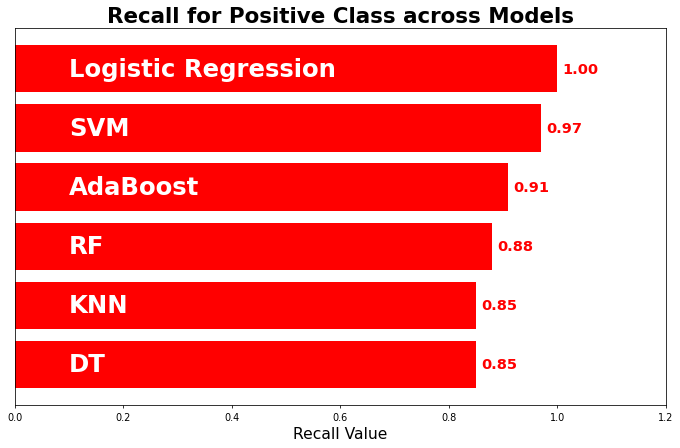

In [128]:
# Sort values based on 'recall_1'
results.sort_values(by='recall_1', ascending=True, inplace=True)
recall_1_scores = results['recall_1']

# Plot the horizontal bar chart
fig, ax = plt.subplots(figsize=(12, 7), dpi=70)
ax.barh(results.index, recall_1_scores, color='red')

# Annotate the values and indexes
for i, (value, name) in enumerate(zip(recall_1_scores, results.index)):
    ax.text(value + 0.01, i, f"{value:.2f}", ha='left', va='center', fontweight='bold', color='red', fontsize=15)
    ax.text(0.1, i, name, ha='left', va='center', fontweight='bold', color='white', fontsize=25)

# Remove yticks
ax.set_yticks([])

# Set x-axis limit
ax.set_xlim([0, 1.2])

# Add title and xlabel
plt.title("Recall for Positive Class across Models", fontweight='bold', fontsize=22)
plt.xlabel('Recall Value', fontsize=16)
plt.show()

## Final Conclusion

Putting the six models side by side (sorted by recall on the positive/disease class, since that's the metric we care about most for this problem):

| Model | Recall (1) | Precision (1) | Recall (0) | Accuracy |
|---|---|---|---|---|
| Logistic Regression | 1.00 | 0.54 | 0.00 | 0.54 |
| SVM | 0.97 | 0.73 | 0.57 | 0.79 |
| AdaBoost | 0.91 | 0.77 | 0.68 | 0.80 |
| Random Forest | 0.88 | 0.83 | 0.79 | 0.84 |
| KNN | 0.85 | 0.85 | 0.82 | 0.84 |
| Decision Tree | 0.85 | 0.78 | 0.71 | 0.79 |

At first glance, Logistic Regression looks like the winner since it caught 100% of the positive cases. But looking at its `recall_0` (0.00) and `precision_0` (0.00), it's clear this model just predicted **every single patient as having heart disease**. That's not a real skill — recall of 1.00 is trivial to get if you never predict the negative class at all. This most likely happened because of how strong the L1 penalty ended up being (`C=0.01` shrank too many coefficients toward zero) combined with the class balance in this small dataset. So I'm ruling this one out despite the top-line number.

SVM has a similarly lopsided pattern, though less extreme — it flags a lot of healthy patients (`recall_0` of only 0.57) in order to catch nearly all the disease cases. In a real clinical setting that means a lot of unnecessary follow-up testing for healthy patients, which has its own costs.

**Random Forest looks like the best overall choice.** It has the highest accuracy (0.84), a strong recall on the positive class (0.88 — it still catches most heart disease cases), and unlike Logistic Regression or SVM, it doesn't sacrifice the negative class to get there (`recall_0` of 0.79). AdaBoost is a reasonable second option if the priority is squeezed slightly more toward catching positive cases (recall 0.91) at some cost to precision.

**Next steps if I had more time:**
* Investigate why Logistic Regression collapsed to a degenerate solution — try a lighter regularization grid (larger C values) or check for multicollinearity among the one-hot encoded features.
* Try adjusting the classification threshold (instead of the default 0.5) on Random Forest or AdaBoost to push recall even higher without fully sacrificing precision, since threshold tuning is usually a better lever than picking a worse-balanced model.
* Given the small dataset (303 patients), cross-validate the final model choice more rigorously (e.g., repeated stratified k-fold) before trusting these single train/test split numbers too heavily.
